In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np
 
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

from tqdm import tqdm

import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"

from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

### Text-based visualization with colored boxes (like highlighted sentence)
from IPython.display import HTML, display
import matplotlib.colors as mcolors
import matplotlib as mpl


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Set input strings

In [115]:
front_pad = 2
back_pad = 0

system_prompt = "You are an expert of verse-to-verse translation. "

In [116]:
### Pad inputs with BOS tokens
front_pad = 2

### Dante
# string = "Italiano: Ma quando tu sarai nel dolce mondo, priegoti ch'a la mente altrui mi rechi: English: But when you have returned to the sweet world, I pray you bring me to men's memory"

### Trilingual translations
# string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
# string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"
 
### Skip delimiters for time-series data
skip_delimiters = False

In [173]:
full_Jacobian = False   
use_low_rank_fisher = True 
# k = 4
k = 8
Temperature_scope = True

### Load models

In [174]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()  



19618

In [175]:
# Load the tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "meta-llama/Llama-2-7b-chat-hf"

if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
    
model.eval();

In [176]:
sys_prompt_tokens = tokenizer(system_prompt, add_special_tokens=False)["input_ids"]

sys_token_len = len(sys_prompt_tokens)

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

# Prepare input: pad both ends with special tokens
input_ids_list = []

# Pad the front
if bos_token_id is not None:
    input_ids_list += [bos_token_id] * front_pad

# Add system prompt
input_ids_list += sys_prompt_tokens
# Main tokens
input_ids_list += tokenizer(string, add_special_tokens=False)["input_ids"]

# Pad the back
if eos_token_id is not None:
    input_ids_list += [eos_token_id] * back_pad

input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(model.device)
attention_mask = torch.ones_like(input_ids)

print("input_ids:", input_ids)
print("vocab size:", model.config.vocab_size)
assert input_ids.max() < model.config.vocab_size

seq_len = input_ids.size(1)

# Optional: print tokens
for i, tok in enumerate(input_ids[0]):
    print(i, tok.item(), repr(tokenizer.decode(tok.item(), skip_special_tokens=False)))

decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]

print(decoded_tokens)


input_ids: tensor([[128000, 128000,   2675,    527,    459,   6335,    315,  33487,   4791,
             12,   4550,  14807,     13,    220,  33179,     25,  24934,   6127,
           4466,  26798,     82,  20786,  14104,    597,  12119,   1604,   1901,
          52178,  76499,     13,   6498,     25,   1115,    374,    264,   5684,
            389,  59557,  63124]])
vocab size: 128256
0 128000 '<|begin_of_text|>'
1 128000 '<|begin_of_text|>'
2 2675 'You'
3 527 ' are'
4 459 ' an'
5 6335 ' expert'
6 315 ' of'
7 33487 ' verse'
8 4791 '-to'
9 12 '-'
10 4550 'verse'
11 14807 ' translation'
12 13 '.'
13 220 ' '
14 33179 'German'
15 25 ':'
16 24934 ' Dies'
17 6127 ' ist'
18 4466 ' ein'
19 26798 ' Auf'
20 82 's'
21 20786 'atz'
22 14104 ' über'
23 597 ' k'
24 12119 'aus'
25 1604 'ale'
26 1901 ' Z'
27 52178 'usch'
28 76499 'reibung'
29 13 '.'
30 6498 ' English'
31 25 ':'
32 1115 ' This'
33 374 ' is'
34 264 ' a'
35 5684 ' paper'
36 389 ' on'
37 59557 ' causal'
38 63124 ' attribution'
['', '', 'Y

In [177]:
### Set which tokens to perform gradients on
### Skip comma delimiters

if skip_delimiters:
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),2)]
else:
    ### all positions
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),1)]

print(grad_idx)

[14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


### Construct backprop variables

In [178]:
embedding_layer = model.get_input_embeddings()
d_model = embedding_layer.embedding_dim

residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=model.device))
presence = torch.ones(len(decoded_tokens), 1, device=model.device)


### Customize forward function

In [179]:
forward_pass = JCBScope_utils.customize_forward_pass(model, residual, presence, input_ids, grad_idx, attention_mask)

In [180]:
import torch


batch_size = 16
# batch_size = 2

loss_position = grad_idx[-1]-1


import time

if Temperature_scope:
    if residual.grad is not None:
        residual.grad = None
    tic = time.time()
    loss, logits = forward_pass(loss_position=loss_position, 
                                hidden_norm_as_loss=True)
    forward_toc = time.time()
    print(f"Time taken for hidden_norm_as_loss forward: {forward_toc - tic:.3f} seconds")
    temperature_grads = torch.autograd.grad(loss, residual, retain_graph=True)[0]
    toc = time.time()
    print(f"Time taken for hidden_norm_as_loss grad: {toc - forward_toc:.3f} seconds")

probed_Jacobian = None  # Set by full Jacobian or remains None for low-rank
if full_Jacobian and not use_low_rank_fisher:
    N_probes = residual.shape[-1]
    projection_probes = torch.eye(N_probes, residual.shape[-1], device=model.device, dtype=residual.dtype)
    losses, logits = forward_pass(loss_position=loss_position, projection_probe = projection_probes)
    num_losses = losses.numel()
    grads_list = []
    batch_tic = time.time()
    for i in tqdm(range(0, num_losses, batch_size), desc="Jacobian (multi-loss) batches"):
        
        end = min(i + batch_size, num_losses)
        eye_batch = torch.eye(num_losses, device=losses.device, dtype=losses.dtype)[i:end]
        grads_batch = torch.autograd.grad(
            outputs=losses,
            inputs=residual,
            grad_outputs=eye_batch,
            is_grads_batched=True,
            retain_graph=True if end < num_losses else False, # only keep graph if more batches remain
        )[0]
        grads_list.append(grads_batch)
    batch_toc = time.time()
    print(f"Time for multi_loss_Jacobian: {batch_toc - batch_tic:.3f} seconds")
    grads = torch.cat(grads_list, dim=0)
    probed_Jacobian = grads.detach().cpu().swapaxes(0, 1) # n_token, n_probe, dim
    
    
    

Time taken for hidden_norm_as_loss forward: 0.665 seconds
Time taken for hidden_norm_as_loss grad: 0.504 seconds


In [181]:
if full_Jacobian and not use_low_rank_fisher:
    probed_Jacobian = grads.detach().cpu().swapaxes(0, 1)  # n_token, n_probe, dim
    rms_grad = np.sqrt((probed_Jacobian**2).sum(axis=-1).mean(axis=-1))
    frob_norm_grad = np.sqrt((probed_Jacobian**2).sum(axis=(1, 2)))

### Compute FIM from Jacobian

torch.linalg.eigh took 0.1536 seconds


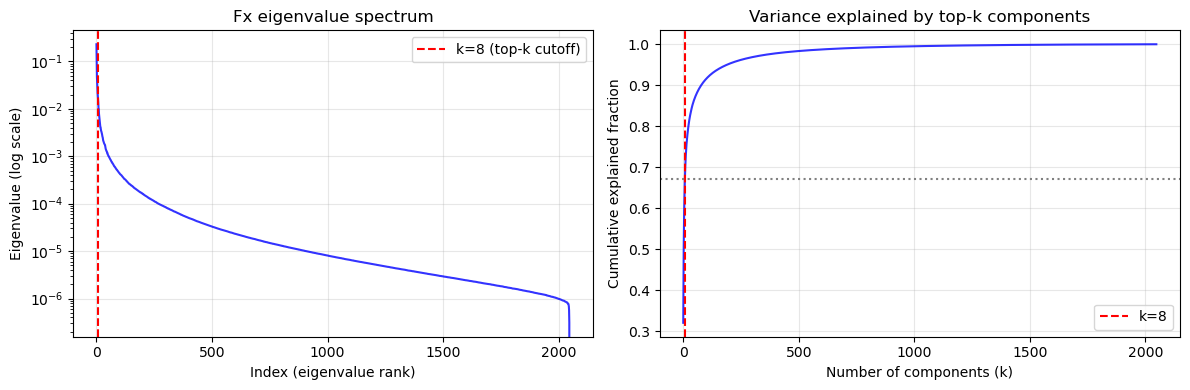

Top-8 explains 67.1% of Fx variance


In [182]:
import torch
import torch.nn.functional as F

def fisher_hidden_from_logits_and_W(logits_t, W, chunk_size=8192):
    """
    logits_t: [V]
    W:        [V, d]
    returns:  Fx [d, d] = W^T (Diag(p) - p p^T) W
    """
    if logits_t.ndim != 1:
        raise ValueError(f"logits_t must be 1D [V], got {tuple(logits_t.shape)}")
    if logits_t.numel() != W.shape[0]:
        raise ValueError(f"logits_t has {logits_t.numel()} entries but W has vocab {W.shape[0]}")

    p = F.softmax(logits_t, dim=-1).to(dtype=W.dtype)  # [V]

    V, d = W.shape
    S  = torch.zeros(d, d, device=W.device, dtype=W.dtype)  # sum_i p_i w_i w_i^T
    mu = torch.zeros(d,   device=W.device, dtype=W.dtype)   # sum_i p_i w_i

    for i in range(0, V, chunk_size):
        Wi = W[i:i+chunk_size]                 # [c, d]
        pi = p[i:i+chunk_size].unsqueeze(1)    # [c, 1]
        Ww = Wi * pi                           # [c, d]

        S  += Wi.T @ Ww
        mu += Ww.sum(dim=0)

    return S - torch.outer(mu, mu)

lm_head = JCBScope_utils.get_lm_head(model)
W = lm_head.weight.to(model.device)  # [V, 2048]

t = loss_position
logits_t = logits[t].to(model.device)  # [V]

with torch.no_grad():
    Fx = fisher_hidden_from_logits_and_W(logits_t, W, chunk_size=8192)  # [2048,2048]

    # Eigendecomposition of symmetric Fx: Fx = U @ diag(eigvals) @ U^T
    # eigh returns eigenvalues in ascending order
    start_eigh = time.time()
    eigvals, U_full = torch.linalg.eigh(Fx)
    end_eigh = time.time()
    print(f"torch.linalg.eigh took {end_eigh - start_eigh:.4f} seconds")
    eigvals = eigvals.cpu().numpy()
    U_full = U_full.to(Fx.device)  # [d, d], columns are eigenvectors

# --- Plot spectrum of Fx for choosing k ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: eigenvalues (descending) on linear scale
ax = axes[0]
eigvals_desc = np.sort(eigvals)[::-1]
ax.semilogy(np.arange(len(eigvals_desc)), eigvals_desc + 1e-12, 'b-', alpha=0.8)
ax.axvline(x=k, color='r', linestyle='--', label=f'k={k} (top-k cutoff)')
ax.set_xlabel('Index (eigenvalue rank)')
ax.set_ylabel('Eigenvalue (log scale)')
ax.set_title('Fx eigenvalue spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: cumulative explained fraction
ax = axes[1]
total = eigvals_desc.sum()
cumfrac = np.cumsum(eigvals_desc) / total if total > 0 else np.zeros_like(eigvals_desc)
ax.plot(np.arange(len(cumfrac)), cumfrac, 'b-', alpha=0.8)
ax.axvline(x=k, color='r', linestyle='--', label=f'k={k}')
_k_plot = min(max(1, k), len(cumfrac))
ax.axhline(y=cumfrac[_k_plot - 1], color='gray', linestyle=':')
ax.set_xlabel('Number of components (k)')
ax.set_ylabel('Cumulative explained fraction')
ax.set_title('Variance explained by top-k components')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Top-{k} explains {100*cumfrac[k-1]:.1f}% of Fx variance")

In [183]:


if use_low_rank_fisher:
    # Low-rank SVD: Fx ≈ U_k S_k U_k^T. Pull-back: J^T Fx J ≈ (J^T U_k) S_k (U_k^T J)
    # U_k^T J is a VJP: use projection_probe = U_k.T (rows = top-k eigenvectors)
    k_actual = min(k, len(eigvals))
    idx_top = np.argsort(eigvals)[::-1][:k_actual].copy()  # avoid negative-stride
    U_k = U_full[:, idx_top].clone().to(model.device)  # [d, k_actual]
    S_k = torch.tensor(eigvals[idx_top].copy(), device=model.device, dtype=W.dtype)
    S_k_diag = torch.diag(S_k)

    projection_probes_lowrank = U_k.T  # [k_actual, d] - rows are vectors for VJP
    losses_lr, _ = forward_pass(loss_position=loss_position, projection_probe=projection_probes_lowrank)
    eye_k = torch.eye(k_actual, device=losses_lr.device, dtype=losses_lr.dtype)
    tic = time.time()
    grads_lr = torch.autograd.grad(outputs=losses_lr, inputs=residual, grad_outputs=eye_k, is_grads_batched=True)[0]
    toc = time.time()
    print(f"low-rank fisher took {toc - tic:.4f} seconds")
    

    F_all_trace = np.zeros(len(grad_idx))
    for tau in range(grads_lr.shape[1]):
        UkT_J = grads_lr[:, tau, :]  # [k, d_model]
        M = UkT_J @ UkT_J.T  # [k, k] = (U_k^T J)(J^T U_k)
        tr_F_tau = (S_k_diag * M).trace().item()
        F_all_trace[tau] = tr_F_tau

    F_all = None  # Not computed for low-rank (only trace needed for Fisher Scope)
    probed_Jacobian = None  # Not used in low-rank path
    print(f"Low-rank Fisher: k={k_actual}, backward passes={k_actual} (vs {d_model} for full)")    
else:
    J_all = probed_Jacobian.to(model.device, dtype=W.dtype)  # [n_token,2048,2048]
    with torch.no_grad():
        tmp   = Fx.unsqueeze(0) @ J_all                  # [n_token,2048,2048]
        F_all = J_all.transpose(1,2) @ tmp               # [n_token,2048,2048]
    F_all_trace = np.array([torch.trace(F_all[i]).item() for i in range(F_all.shape[0])])
    print(F_all.shape)  # torch.Size([n_token, 2048, 2048])


low-rank fisher took 0.5259 seconds
Low-rank Fisher: k=8, backward passes=8 (vs 2048 for full)


In [184]:
# # Deep clean CUDA GPU memory
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()
# gc.collect()  


In [185]:
if not use_low_rank_fisher:
    frob_norm_per_token = np.array([
        torch.sqrt((F_all[i] ** 2).sum()).item() for i in range(probed_Jacobian.shape[0])
    ])
    F_all_trace = np.array([torch.trace(F_all[i]).item() for i in range(F_all.shape[0])])
# else: F_all_trace already set in FIM cell

temperature_mag_per_token = temperature_grads.norm(dim=-1).detach().cpu()

In [186]:
def plotter(grad_magnitude, plot_title):
    print(plot_title)
    log_color = False
    exclude_target = 0
    cmap = plt.get_cmap('Blues')

    if exclude_target:
        optimized_tokens = [decoded_tokens[idx] for idx in grad_idx][:-1]
    else: 
        optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]

    tick_label_text = optimized_tokens.copy()
                
    # Normalize grad_magnitude for color mapping
    log_norm = Log_Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())
    norm = Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())


    bar_idx = grad_idx.index(loss_position+1)

    if log_color:
        colors = cmap(log_norm(grad_magnitude))
    else:
        colors = cmap(norm(grad_magnitude))

    # Build HTML with colored boxes around each word, using bold font
    def rgba_to_css(rgba):
        """Convert matplotlib RGBA to CSS rgba string"""
        return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"

    def get_text_color(bg_rgba):
        """Return white or black text based on background luminance"""
        luminance = 0.299 * bg_rgba[0] + 0.587 * bg_rgba[1] + 0.114 * bg_rgba[2]
        return "white" if luminance < 0.5 else "black"

    html_parts = []
    for i, (token, color) in enumerate(zip(tick_label_text, colors)):
        bg_color = rgba_to_css(color)
        text_color = get_text_color(color)
        
        # Special styling for target token
        if i == bar_idx:
            # bg_color = "black"
            bg_color = "red"
            text_color = "white"
        
        # Clean up token display (remove leading space for display but keep for meaning)
        # display_token = token if token.strip() else "·"  # show dot for whitespace-only tokens
        # Show dot for tokens that are purely whitespace, but do not remove leading space otherwise
        # display_token = "1"+token 
        display_token = token 
        # print(display_token)
        
        html_parts.append(
            f'<span style="'
            f'background-color: {bg_color}; '
            f'color: {text_color}; '
            # f'padding: 0px 9px; '
            f'padding: 0px 0px; '
            # f'margin: 2px; '
            f'margin: 0px; '
            # f'border-radius: 8px; '
            f'border-radius: 0px; '
            f'font-family: monospace; '
            f'font-size: 16px; '
            f'display: inline-block; '
            f'font-weight: bold;'   # <-- bold font here
            # f'">{display_token}</span>'
            # To prevent collapsing of white spaces when displaying the token—including leading spaces—we can use CSS 'white-space: pre' so all spaces are rendered as-is.
            # This ensures that tokens like ' am' keep their leading space in the browser.
            f'white-space: pre;">{display_token}</span>'
        )

    # === OPTION A: HTML display with fixed width ===
    html_str = f'''
    <div style="
        background: white; 
        padding: 20px; 
        border-radius: 8px; 
        line-height: 2.2;
        width: 550px;
        # width: 1100px;
    ">
        {"".join(html_parts)}
    </div>
    '''
    display(HTML(html_str))


    # Adjust the figure size to better fit the colorbar and avoid cutoff
    fig_bar, ax_bar = plt.subplots(figsize=(0.4, 2.2), dpi=150)
    fig_bar.subplots_adjust(left=0.3, right=0.7, bottom=0.1, top=0.9)

    cbar = mpl.colorbar.ColorbarBase(
        ax_bar,
        cmap=cmap,
        norm=log_norm if log_color else norm,
        orientation='vertical'
    )
    # if normalize == True:
    #     cbar.set_label('Normalized influence', fontsize=12)    
    # else:
    #     cbar.set_label('Influence', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')
    plt.show()


Fisher Scope


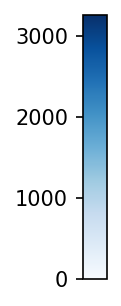

In [187]:
grad_magnitude = F_all_trace 
plot_title = "Fisher Scope"

plotter(grad_magnitude, plot_title)


Temperature Scope


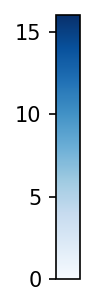

In [188]:
grad_magnitude = temperature_mag_per_token
plot_title = "Temperature Scope"

plotter(grad_magnitude, plot_title)